In [5]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [6]:
class AgentState(TypedDict):
    name : str
    target : int
    guesses : List[int]
    attempts : int
    hint : str
    lower_bound : int
    upper_bound : int

In [7]:
def setup_node(state: AgentState) -> AgentState:
    """This is the setup node of the game."""

    state['name'] = f"Welcome, {state['name']} !!!"
    state['target'] = random.randint(1, 20)
    state['guesses'] = []
    state['attempts'] = 0
    state['lower_bound'] = 1
    state['upper_bound'] = 20
    state['hint'] = "The game has started! Guess a number"
    return state

In [38]:
def guess_node(state: AgentState) -> AgentState:
    """This is the guessing node."""

    possible_guesses = []
    for i in range(state['lower_bound'], state['upper_bound']+1):
        if(i not in state['guesses']):
            possible_guesses.append(i)

    if(len(possible_guesses) > 0):
        guess = random.choice(possible_guesses)
    else:
        guess = random.randint(state['lower_bound'], state['upper_bound'])

    state['guesses'].append(guess)
    state['attempts'] += 1
    print(f"Attempt {state['attempts']}, Guess = {guess} [Current range : ({state['lower_bound']}, {state['upper_bound']})]")
    return state

In [39]:
def hint_node(state: AgentState) -> AgentState:
    """This is the hint node."""

    latest_guess = state['guesses'][-1]
    target = state['target']

    if(latest_guess < target):
        state['hint'] = f"The number {latest_guess} is too low. Try higher!"

        state['lower_bound'] = max(state['lower_bound'], latest_guess+1)
        print(f"Hint: {state['hint']}")
    
    elif(latest_guess > target):
        state['hint'] = f"The number {latest_guess} is too high. Try lower!"

        state['upper_bound'] = min(state['upper_bound'], latest_guess-1)
        print(f"Hint: {state['hint']}")

    else:
        state['hint'] = f"Success, You fount the correct number {state['target']} in {state['attempts']} attempts."
        print(f"Success: {state['hint']}")

    return state

In [40]:
def should_continue_node(state: AgentState) -> AgentState:
    """This is the deciding node which decides whether to continue next or not."""

    latest_guess = state['guesses'][-1]
    cnt_attempt = state['attempts']

    if(latest_guess == state['target']):
        print("Game Over, the number found.")
        return "exit_edge"
    elif(cnt_attempt >= 7):
        print("Game Over, maximum attempts reached.")
        return "exit_edge"
    else:
        return "conitnue_edge"

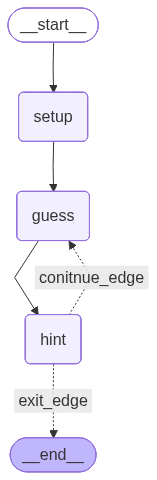

In [41]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint", hint_node)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")
graph.add_conditional_edges(
    "hint",
    should_continue_node,
    {
        #edge : node
        "exit_edge" : END,
        "conitnue_edge" : "guess"
    }
)

app = graph.compile()
app

In [42]:
app.invoke({"name": "Gaurang", "attempts": 0, "guesses": [], "lower_bound": 1, "upper_bound": 20})

Attempt 1, Guess = 17 [Current range : (1, 20)]
Hint: The number 17 is too low. Try higher!
Attempt 2, Guess = 20 [Current range : (18, 20)]
Hint: The number 20 is too high. Try lower!
Attempt 3, Guess = 18 [Current range : (18, 19)]
Hint: The number 18 is too low. Try higher!
Attempt 4, Guess = 19 [Current range : (19, 19)]
Success: Success, You fount the correct number 19 in 4 attempts.
Game Over, the number found.


{'name': 'Welcome, Gaurang !!!',
 'target': 19,
 'guesses': [17, 20, 18, 19],
 'attempts': 4,
 'hint': 'Success, You fount the correct number 19 in 4 attempts.',
 'lower_bound': 19,
 'upper_bound': 19}